         x1        x2  etiqueta
0 -0.008864  0.113353         0
1  0.242456 -0.075897         0
2 -0.014196 -0.070382         0
3 -0.165579 -0.143002         0
4  0.202125  0.327485         0


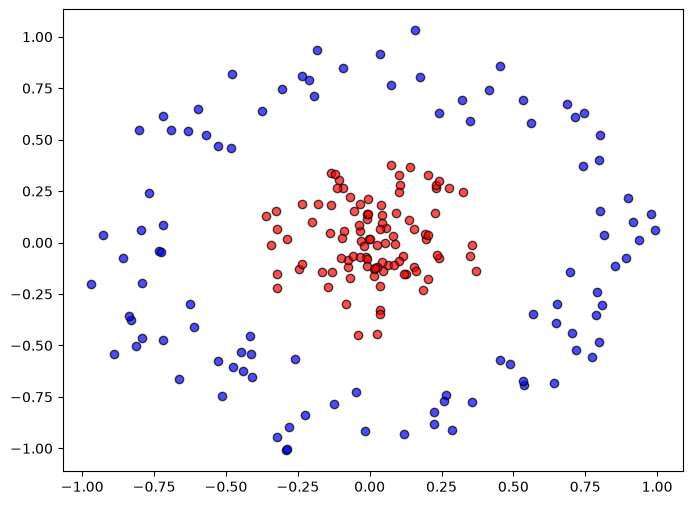

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
 
# 1. Configurar semilla para reproducibilidad
np.random.seed(42)
 
# 2. Definir parámetros
n_samples_per_class = 100  # 100 para malignas (0) y 100 para benignas (1)
n_total = n_samples_per_class * 2
 
# 3. Generar círculos concéntricos
# Clase 0: Círculo interno (Malignas)
theta_0 = np.random.uniform(0, 2 * np.pi, n_samples_per_class)
r_0 = np.random.uniform(0, 0.4, n_samples_per_class)  # Radio interno pequeño
x1_0 = r_0 * np.cos(theta_0)
x2_0 = r_0 * np.sin(theta_0)
y_0 = np.zeros(n_samples_per_class)
 
# Clase 1: Círculo externo (Benignas)
theta_1 = np.random.uniform(0, 2 * np.pi, n_samples_per_class)
r_1 = np.random.uniform(0.7, 1.0, n_samples_per_class)  # Radio externo grande
x1_1 = r_1 * np.cos(theta_1)
x2_1 = r_1 * np.sin(theta_1)
y_1 = np.ones(n_samples_per_class)
 
# 4. Combinar los datos
x1 = np.concatenate([x1_0, x1_1])
x2 = np.concatenate([x2_0, x2_1])
etiqueta = np.concatenate([y_0, y_1])
 
# 5. Agregar ruido al valor de x2
ruido = np.random.normal(0, 0.08, n_total)  # Ruido gaussiano con media 0 y desviación estándar 0.08
x2 = x2 + ruido
 
# 6. Crear un DataFrame de Pandas
df_celulas = pd.DataFrame({
    'x1': x1,
    'x2': x2,
    'etiqueta': etiqueta.astype(int)
})
 
# Mostrar las primeras 5 filas del dataset
print(df_celulas.head())
 
# 7. (Opcional) Visualizar los datos generados
plt.figure(figsize=(8, 6))
plt.scatter(df_celulas[df_celulas['etiqueta'] == 0]['x1'], 
            df_celulas[df_celulas['etiqueta'] == 0]['x2'], 
            color='red', label='Maligna (0)', alpha=0.7, edgecolors='k')
plt.scatter(df_celulas[df_celulas['etiqueta'] == 1]['x1'], 
            df_celulas[df_celulas['etiqueta'] == 1]['x2'], 
            color='blue', label='Benigna (1)', alpha=0.7, edgecolors='k')

Iteration 1, loss = 0.79953946
Validation score: 0.500000
Iteration 2, loss = 0.74395178
Validation score: 0.500000
Iteration 3, loss = 0.71872881
Validation score: 0.500000
Iteration 4, loss = 0.69932005
Validation score: 0.718750
Iteration 5, loss = 0.68487403
Validation score: 0.656250
Iteration 6, loss = 0.67863523
Validation score: 0.500000
Iteration 7, loss = 0.67485674
Validation score: 0.500000
Iteration 8, loss = 0.66981933
Validation score: 0.500000
Iteration 9, loss = 0.66117526
Validation score: 0.500000
Iteration 10, loss = 0.64883208
Validation score: 0.531250
Iteration 11, loss = 0.63572505
Validation score: 0.593750
Iteration 12, loss = 0.62391911
Validation score: 0.593750
Iteration 13, loss = 0.61530813
Validation score: 0.656250
Iteration 14, loss = 0.60678985
Validation score: 0.687500
Iteration 15, loss = 0.59780704
Validation score: 0.687500
Validation score did not improve more than tol=0.001000 for 10 consecutive epochs. Stopping.
Iteraciones realizadas: 15
Prec

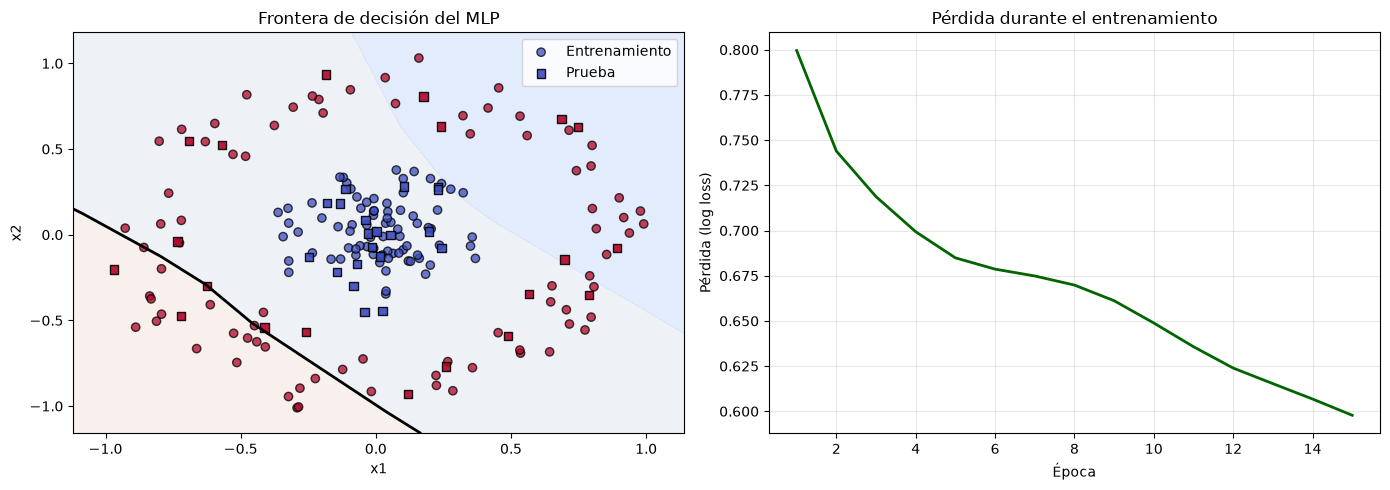

In [10]:
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

X = df_celulas[['x1', 'x2']]
y = df_celulas['etiqueta']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

modelo_mlp = MLPClassifier(
    hidden_layer_sizes=(16, 8, 4),
    learning_rate_init=0.03,
    max_iter=100,
    batch_size=128,
    tol=0.001,
    early_stopping=True,
    n_iter_no_change=10,
    validation_fraction=0.2,
    verbose=True,
    random_state=42,
    activation = 'relu'
)

modelo_mlp.fit(X_train, y_train)

predicciones = modelo_mlp.predict(X_test)
precision = accuracy_score(y_test, predicciones)

print(f'Iteraciones realizadas: {modelo_mlp.n_iter_}')
print(f'Precisión del MLP: {precision:.2f}')

# Crear una malla para visualizar la frontera de decisión
margen = 0.15
x1_min, x1_max = X['x1'].min() - margen, X['x1'].max() + margen
x2_min, x2_max = X['x2'].min() - margen, X['x2'].max() + margen
malla_x1, malla_x2 = np.meshgrid(
    np.linspace(x1_min, x1_max, 300),
    np.linspace(x2_min, x2_max, 300)
)
puntos_malla = pd.DataFrame({
    'x1': malla_x1.ravel(),
    'x2': malla_x2.ravel()
})
probabilidades = modelo_mlp.predict_proba(puntos_malla)[:, 1]
probabilidades = probabilidades.reshape(malla_x1.shape)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Frontera de decisión y datos
axes[0].contourf(
    malla_x1, malla_x2, probabilidades,
    levels=np.linspace(0, 1, 11), cmap='coolwarm', alpha=0.35
)
axes[0].contour(
    malla_x1, malla_x2, probabilidades,
    levels=[0.5], colors='black', linewidths=2
)
axes[0].scatter(
    X_train['x1'], X_train['x2'], c=y_train,
    cmap='coolwarm', edgecolors='black', alpha=0.75, label='Entrenamiento'
)
axes[0].scatter(
    X_test['x1'], X_test['x2'], c=y_test,
    cmap='coolwarm', edgecolors='black', marker='s', alpha=0.9, label='Prueba'
)
axes[0].set_title('Frontera de decisión del MLP')
axes[0].set_xlabel('x1')
axes[0].set_ylabel('x2')
axes[0].legend()

# Evolución de la pérdida
axes[1].plot(
    range(1, len(modelo_mlp.loss_curve_) + 1),
    modelo_mlp.loss_curve_,
    color='darkgreen', linewidth=2
)
axes[1].set_title('Pérdida durante el entrenamiento')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Pérdida (log loss)')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [14]:
#entrenamiento con los datos completos
modelo_mlp.fit(X, y)


Iteration 1, loss = 0.79311940
Validation score: 0.500000
Iteration 2, loss = 0.71796242
Validation score: 0.550000
Iteration 3, loss = 0.68772898
Validation score: 0.625000
Iteration 4, loss = 0.67266649
Validation score: 0.575000
Iteration 5, loss = 0.65293333
Validation score: 0.650000
Iteration 6, loss = 0.62814441
Validation score: 0.650000
Iteration 7, loss = 0.60760275
Validation score: 0.650000
Iteration 8, loss = 0.59178874
Validation score: 0.650000
Iteration 9, loss = 0.57558906
Validation score: 0.650000
Iteration 10, loss = 0.55964302
Validation score: 0.700000
Iteration 11, loss = 0.54271555
Validation score: 0.700000
Iteration 12, loss = 0.52377748
Validation score: 0.700000
Iteration 13, loss = 0.50954772
Validation score: 0.700000
Iteration 14, loss = 0.49427969
Validation score: 0.700000
Iteration 15, loss = 0.46928347
Validation score: 0.700000
Iteration 16, loss = 0.43681209
Validation score: 0.700000
Iteration 17, loss = 0.39614962
Validation score: 0.875000
Iterat

,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(16, ...)"
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the classifier will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",128
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.03
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",100
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary <random_state>`.",42
,"tol tol: float, default=1e-4Tolerance for the optimization. When the loss or score is not improvingby at least ``tol`` for ``n_iter_no_change`` consecutive iterations,unless ``learning_rate`` is set to 'adaptive', convergence isconsidered to be reached and training stops.",0.001
,"verbose verbose: bool, default=FalseWhether to print progress messages to stdout.",True
,"early_stopping early_stopping: bool, default=FalseWhether to use early stopping to terminate training when validationscore is not improving. If set to True, it will automatically setaside ``validation_fraction`` of training data as validation andterminate training when validation score is not improving by at least``tol`` for ``n_iter_no_change`` consecutive epochs. The split isstratified, except in a multilabel setting.If early stopping is False, then the training stops when the trainingloss does not improve by more than ``tol`` for ``n_iter_no_change``consecutive passes over the training set.Only effective when solver='sgd' or 'adam'.",True
,"validation_fraction validation_fraction: float, default=0.1The proportion of training data to set aside as validation set forearly stopping. Must be between 0 and 1.Only used if early_stopping is True.",0.2
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'


In [15]:
#guardar el modelo entrenado
import joblib
joblib.dump(modelo_mlp, 'modelo_mlp_circulos_concentricos.pkl')


['modelo_mlp_circulos_concentricos.pkl']

In [18]:
#predecir 
from sklearn.metrics import classification_report


y_pred = modelo_mlp.predict(X)
print(classification_report(y, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       100
           1       1.00      1.00      1.00       100

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



In [22]:
# Predicción para una nueva célula
nueva_celula = pd.DataFrame({'x1': [0.1], 'x2': [0.1]})

clase_predicha = modelo_mlp.predict(nueva_celula)[0]
probabilidades_nueva = modelo_mlp.predict_proba(nueva_celula)[0]

probabilidad_maligna = probabilidades_nueva[0]
probabilidad_benigna = probabilidades_nueva[1]

print(f'Probabilidad de célula maligna (clase 0): {probabilidad_maligna:.4f}')
print(f'Probabilidad de célula benigna (clase 1): {probabilidad_benigna:.4f}')
print(f'Clase predicha: {clase_predicha}')

nombre_clase = 'maligna' if clase_predicha == 0 else 'benigna'
print(f'La célula se clasifica como: {nombre_clase}')

Probabilidad de célula maligna (clase 0): 0.9975
Probabilidad de célula benigna (clase 1): 0.0025
Clase predicha: 0
La célula se clasifica como: maligna
